In [1]:
!pip install pandas 


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\gasit\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
df=pd.read_csv('online_shoppers_intention.csv')
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [5]:
!pip install matplotlib


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\gasit\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [8]:
import matplotlib.pyplot as plt

# 1. Count the occurrences of 1 (Open) and 0 (Closed)
# value_counts() automatically ignores NaNs by default
status_counts = df['Revenue'].value_counts()

# 2. Prepare the data
# We use .get() to avoid errors if one of the categories is missing
labels = ['Open (1)', 'Closed (0)']
sizes = [status_counts.get(1, 0), status_counts.get(0, 0)]
colors = ['#66b3ff', '#ffcc99'] 

# 3. Create the pie chart
plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', 
        shadow=True, startangle=90)

plt.title('Business Status Distribution (Open vs. Closed)')
plt.axis('equal') 
plt.show()

C:\Users\gasit\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\matplotlib\axes\_axes.py:3368: RuntimeWarning: invalid value encountered in divide
  x = x / sx


RuntimeError: Invalid vertices array.

ValueError: need at least one array to concatenate

<Figure size 700x700 with 1 Axes>

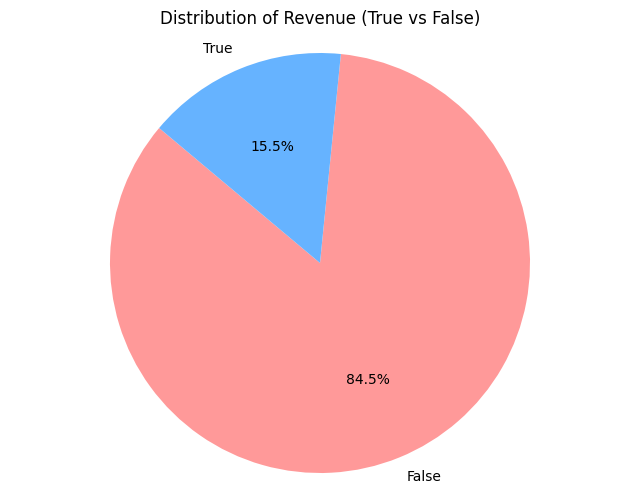

In [9]:
import matplotlib.pyplot as plt

# 1. Count the occurrences of each value in the Revenue column
revenue_counts = df['Revenue'].value_counts()

# 2. Create the pie chart
plt.figure(figsize=(8, 6))
plt.pie(
    revenue_counts, 
    labels=revenue_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=['#ff9999','#66b3ff']
)

plt.title('Distribution of Revenue (True vs False)')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [12]:
# Separate the classes
df_majority = df[df['Revenue'] == False]
df_minority = df[df['Revenue'] == True]

# Determine the number of majority samples
n_majority = len(df_majority)

# Upsample minority class
df_minority_upsampled = df_minority.sample(n=n_majority, replace=True, random_state=42)

# Combine back into a balanced dataframe
df_balanced = pd.concat([df_majority, df_minority_upsampled])

print(df_balanced['Revenue'].value_counts())

Revenue
False    10422
True     10422
Name: count, dtype: int64


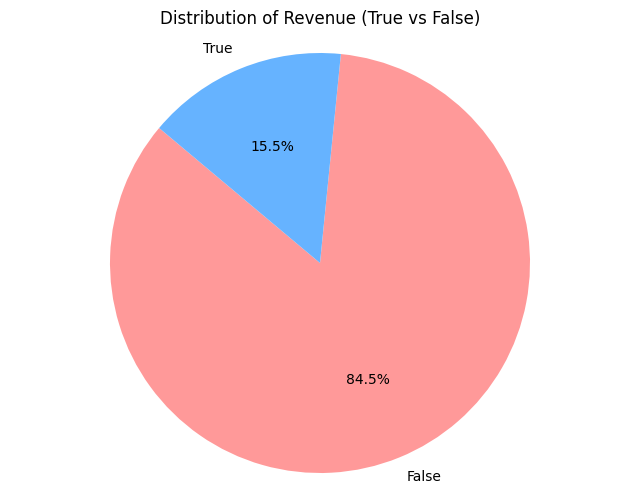

In [11]:
import matplotlib.pyplot as plt

# 1. Count the occurrences of each value in the Revenue column
revenue_counts = df['Revenue'].value_counts()

# 2. Create the pie chart
plt.figure(figsize=(8, 6))
plt.pie(
    revenue_counts, 
    labels=revenue_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=['#ff9999','#66b3ff']
)

plt.title('Distribution of Revenue (True vs False)')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

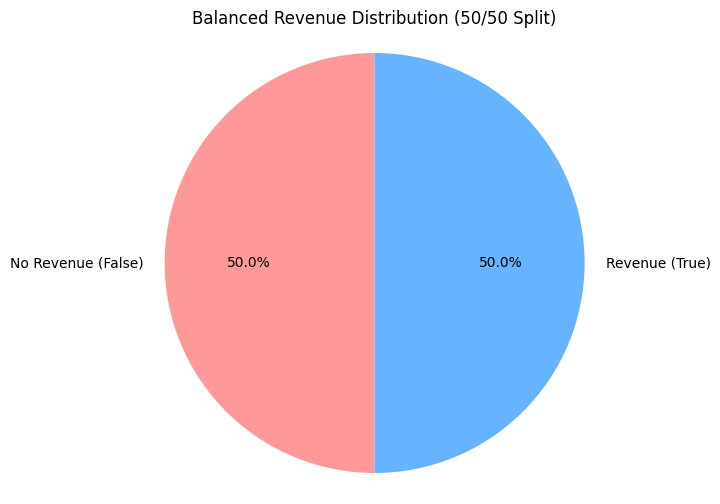

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Separate the classes
df_no_revenue = df[df['Revenue'] == False]
df_revenue = df[df['Revenue'] == True]

# 2. Balance the data (Undersampling)
# We match the count of 'False' to the count of 'True'
n_minority = len(df_revenue)
df_no_revenue_balanced = df_no_revenue.sample(n=n_minority, random_state=42)

# 3. Combine them back
df_balanced = pd.concat([df_no_revenue_balanced, df_revenue])

# 4. Generate the Balanced Pie Chart
balanced_counts = df_balanced['Revenue'].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(
    balanced_counts, 
    labels=['No Revenue (False)', 'Revenue (True)'], 
    autopct='%1.1f%%', 
    colors=['#ff9999','#66b3ff'],
    startangle=90
)

plt.title('Balanced Revenue Distribution (50/50 Split)')
plt.axis('equal')
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Step 1: Convert categorical columns into numerical using One-Hot Encoding
# This handles 'Month', 'VisitorType', and 'Weekend'
df_prepared = pd.get_dummies(df_balanced, columns=['Month', 'VisitorType', 'Weekend'], drop_first=True)

# Step 2: Define Features (X) and Target (y)
X = df_prepared.drop('Revenue', axis=1)
y = df_prepared['Revenue'].astype(int) # Converting True/False to 1/0

# Step 3: Split into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 4: Initialize and Train the Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Step 5: Make predictions and check accuracy
y_pred = model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Model Accuracy: 85.59%

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.84      0.86       590
           1       0.83      0.88      0.86       555

    accuracy                           0.86      1145
   macro avg       0.86      0.86      0.86      1145
weighted avg       0.86      0.86      0.86      1145



In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")

Training rows: 3052
Testing rows: 764


In [16]:
# Create the model instance
model = LogisticRegression()

# Train (fit) the model
model.fit(X_train, y_train)

NameError: name 'LogisticRegression' is not defined

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Scale the features (Important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Initialize and train the model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

# 3. Predict and Evaluate
y_pred_log = log_reg.predict(X_test_scaled)
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_log):.2%}")

Logistic Regression Accuracy: 81.28%


In [18]:
# Check for missing values in each column
print("Missing values per column:")
print(df.isnull().sum())

# Check for total duplicate rows
print(f"\nTotal duplicate rows: {df.duplicated().sum()}")

Missing values per column:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

Total duplicate rows: 125


In [19]:
# 1. Remove rows with missing values
# 'inplace=True' applies the change directly to your dataframe
df.dropna(inplace=True)

# 2. Remove duplicate rows
df.drop_duplicates(inplace=True)

# Verify the new shape of your data
print(f"Cleaned data shape: {df.shape}")

Cleaned data shape: (12205, 18)


In [20]:
import pandas as pd

# Data from the image
new_customer = {
    'Administrative': 0,
    'Administrative_Duration': 0.0,
    'Informational': 0,
    'Informational_Duration': 0.0,
    'ProductRelated': 1,
    'ProductRelated_Duration': 3.0,
    'BounceRates': 0.2,
    'ExitRates': 0.2,
    'PageValues': 0.0,
    'SpecialDay': 0.0,
    'Month': 'Feb',
    'OperatingSystems': 1,
    'Browser': 1,
    'Region': 1,
    'TrafficType': 1,
    'VisitorType': 'Returning_Visitor',
    'Weekend': False
}

# Convert to DataFrame
df_new = pd.DataFrame([new_customer])

In [22]:
# 1. Apply One-Hot Encoding to the new customer
df_new_encoded = pd.get_dummies(df_new)

# 2. Align columns with the training data (fill missing dummies with 0)
df_new_encoded = df_new_encoded.reindex(columns = X.columns, fill_value=0)

# 3. Scale the data (using the SAME scaler from before)
df_new_scaled = scaler.transform(df_new_encoded)

# 4. Predict
prediction = log_reg.predict(df_new_scaled)
probability = log_reg.predict_proba(df_new_scaled)

result = "1" if prediction[0] == 1 else "0"
print(f"Prediction: {result}")
print(f"Confidence: {probability[0][prediction[0]]:.2%}")

Prediction: 0
Confidence: 99.82%
